# Analyzing Open Problems results in a smaller scope

- Using the newest run (2025.10.11) results
- 10 Datasets
    - mouse pancreas atlas
    - diabetic kidney disease
    - immune cell atlas
    - gtex_vg
    - hypomap
    - tabula sapiens
    - zebrafish
    - cengen
    - human immune (immune_cells: from scib benchmark)
    - human pancreas (pancreas: from scib benchmark)
    
  including following dataset features:
    - organism
    - n_tissues
    - size
    - n_genes
    - n_celltypes
    - n_batches
    - batch_imbalance (Coeffiecient of Variance)
    - nested_batch
    - n_donors
    - n_samples
- The metric `kBET` will be excluded since it fails when running on mouse pancreas atlas
- `HVG overlap` will be excluded as it is only computed for very few methods
- Methods that fail often or consistantly perform poorly are excluded (below (and including) BBKNN)

## setting up the packages and dataframe

In [2]:
import os
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import time
import seaborn as sns  # optional, just for color if you like
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.linear_model import LinearRegression
import numpy as np


In [50]:
base_dir = "/Users/seohyon/resources/results"

# will track only these methods (above BBKNN)
keep_methods = [
    "embed_cell_types_jittered",
    "embed_cell_types",
    "shuffle_integration",
    "shuffle_integration_by_cell_type",
    "shuffle_integration",
    "scanvi",
    "combat",
    "scvi",
    "harmony",
    "harmonypy",
    "batchelor_fastmnn",
    "liger",
    "pyliger",
    "scalex",
    "uce",
    "no_integration",
    "no_integration_batch",
    "scanorama"
]

yaml_path = "/Users/seohyon/resources/results/run_2025-10-11_13-28-50/score_uns.yaml"
rows = []

with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

for entry in data:
    method = entry.get("method_id", "").strip().lower()

    # keep only desired methods
    if method not in keep_methods:
        continue

    metrics = entry.get("metric_ids", [])
    values = entry.get("metric_values", [])

    for m_id, m_val in zip(metrics, values):
        rows.append({
            "dataset_id": entry.get("dataset_id"),
            "method_id": method,
            "metric_id": m_id,
            "metric_value": m_val
        })

In [51]:
# Step 2 — Create one big DataFrame
df = pd.DataFrame(rows)
df = df.dropna(subset=["metric_value"]).copy() # drop NaN
# df = df[df["metric_id"] != "kbet"].copy() # drop kbet
df = df[~df["metric_id"].isin(["kbet", "hvg_overlap"])].copy() # drop unwanted metrics
df["dataset_id"] = df["dataset_id"].str.split("/").str[-1] # clean the dataset id

# # Step 3 — Split into separate tables per dataset_id
# datasets = {}
# for dataset_id, sub_df in df.groupby("dataset_id"):
#     datasets[dataset_id] = sub_df.reset_index(drop=True)
#     print(f"\n=== Dataset: {dataset_id} ===")
#     print(sub_df)

In [52]:
# adding dataset metadata to the dataframe
meta = pd.read_csv("/Users/seohyon/resources/Batch_Integration_Dataset - Tabellenblatt3.csv")

df = pd.merge(df, meta, left_on="dataset_id", right_on="dataset", how="inner").drop(columns=["dataset"])

In [53]:
# control methods - flags
control_type_map = {
    "embed_cell_types": "positive",
    "embed_cell_types_jittered": "positive",
    "shuffle_integration": "negative",
    "shuffle_integration_by_batch": "negative",
    "shuffle_integration_by_cell_type": "negative",
    "no_integration": "baseline",
    "no_integration_batch": "baseline",
}

df["control_type"] = df["method_id"].map(control_type_map).fillna("none") # none for non-control methods
df["control_group"] = df["control_type"].apply(
    lambda x: "non-control method" if x == "none" else "control method"
) # easier for plotting: control vs non-control

In [109]:
# mapping categorical to binary for plotting
df["nested_batches_num"] = df["nested_batches"].map({"No": 0, "Yes": 1})

Sub-dataframe per metric for plotting:

In [110]:
for metric in df["metric_id"].unique():
    globals()[f"df_{metric}"] = df[df["metric_id"] == metric].sort_values("size")

## Correlation between one metric and one feature (per method)

- spearman correlation bar plot to see which methods to focus on
    - a line plot connecting each methods per metric-feature would be nice to look together as well
- high correlation & visible linear relation -> linear regression
- no, actually just lm plot straight away?
- take one postive control method, one negative, and one integration method that I understand so that I have an expectation
    - scvi, harmony, scanorama
- random effect: method
- if I don’t see a linear trend: move on to the next metric; maybe there’s a way to see them all at once as well idk
- if the method is a control method, the line is coloured orange, if not, blue

### helper function for spearman correlation

In [125]:
# helper function
def spearman_by_method(df_metric, feature, plot=True, palette="viridis"):
    correlations = []

    for method in df_metric["method_id"].unique():
        df_m = df_metric[df_metric["method_id"] == method]

        if len(df_m) < 2:
            continue

        # Drop NaNs only for the correlation calculation
        valid = df_m[[feature, "metric_value"]].dropna()

        if len(valid) < 2:
            rho, pval = np.nan, np.nan
        else:
            rho, pval = spearmanr(valid[feature], valid["metric_value"])

        correlations.append({
            "method": method,
            "spearman_rho": rho,
            "p_value": pval,
            "n_points": len(df_m),
            "control_group": df_m.loc[df_m["method_id"] == method, "control_group"].iloc[0]
        })

    corr_df = pd.DataFrame(correlations).sort_values("spearman_rho", ascending=False)

    # ---------- PLOT ----------
    if plot and not corr_df.empty:
        plt.figure(figsize=(10, 6))
        sns.barplot(
            data=corr_df,
            x="spearman_rho",
            y="method",
            orient="h",
            hue="control_group",
        )
        plt.axvline(0, color="black", linewidth=1)
        plt.title(f"Spearman correlation: metric_value vs {feature}")
        plt.xlabel("Spearman ρ")
        plt.ylabel("Method")
        plt.tight_layout()
        plt.show()

    return corr_df

### ari vs size - harmonypy, liger, batchelor_fastmnn, combat?

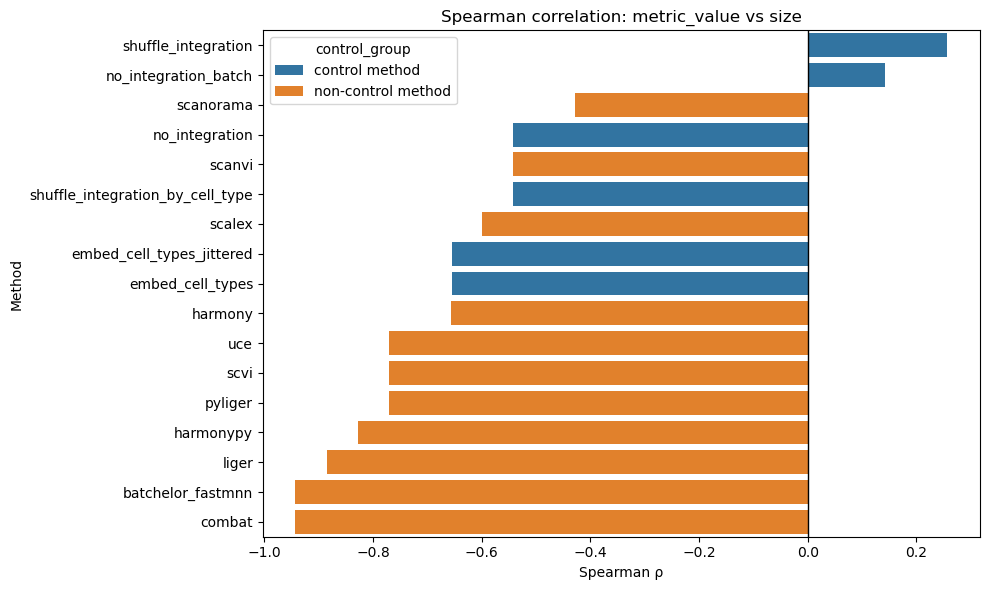

,method,spearman_rho,p_value,n_points,control_group
9,shuffle_integration,0.257143,0.622787,6,control method
10,no_integration_batch,0.142857,0.787172,6,control method
0,scanorama,-0.428571,0.396501,6,non-control method
1,no_integration,-0.542857,0.265703,6,control method
11,scanvi,-0.542857,0.265703,6,non-control method
12,shuffle_integration_by_cell_type,-0.542857,0.265703,6,control method
3,scalex,-0.600000,0.208000,6,non-control method
7,embed_cell_types_jittered,-0.654654,0.158302,6,control method
13,embed_cell_types,-0.654654,0.158302,6,control method
5,harmony,-0.657143,0.156175,6,non-control method


In [56]:
spearman_by_method(df_ari, "size")

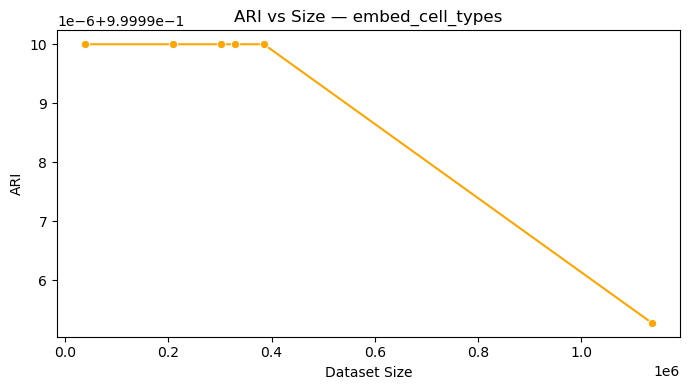

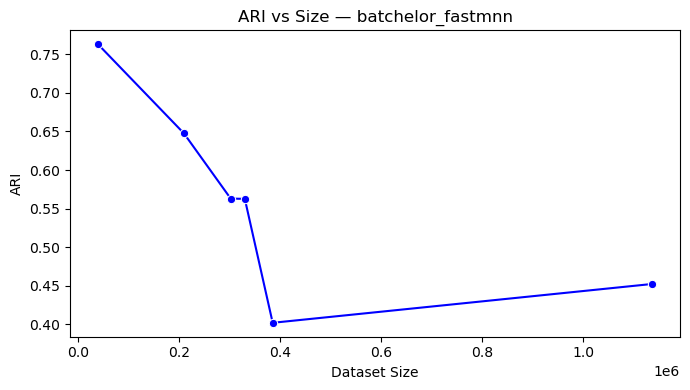

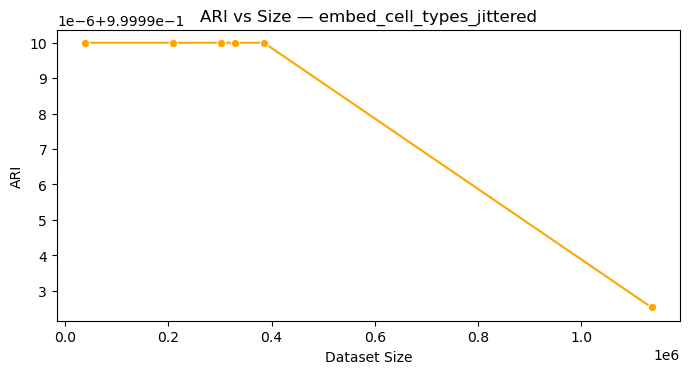

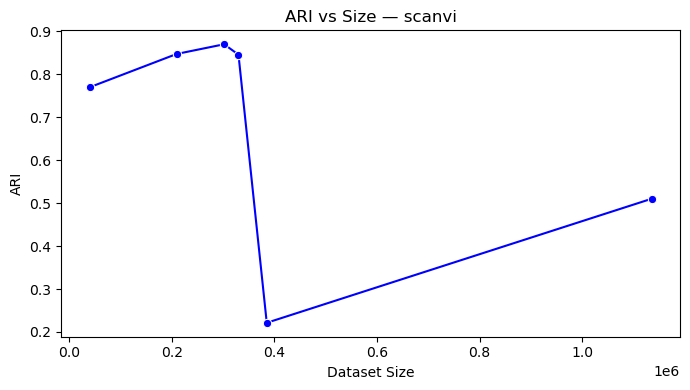

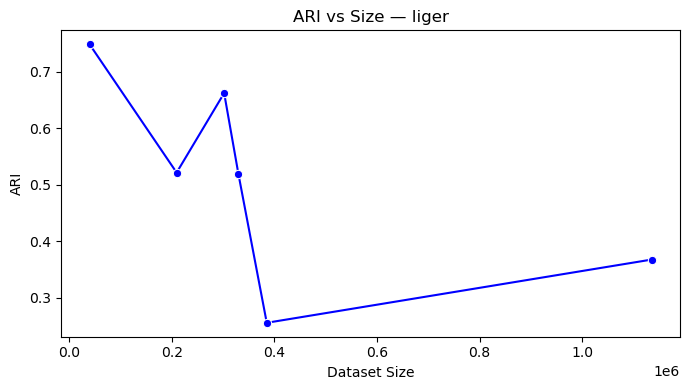

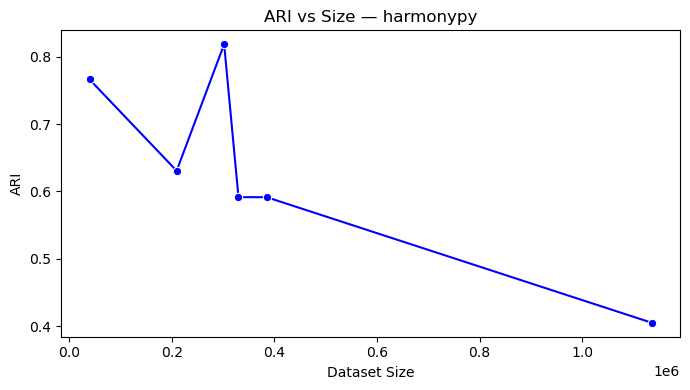

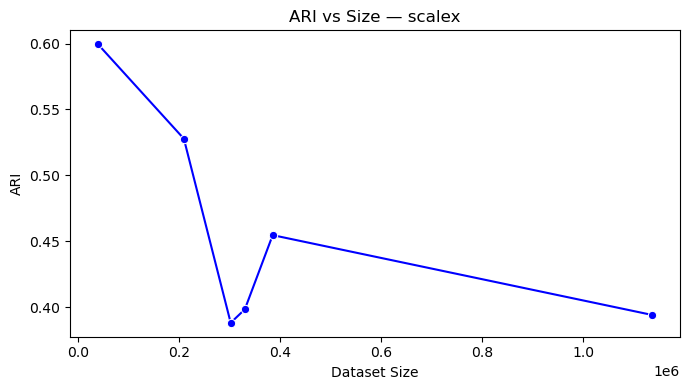

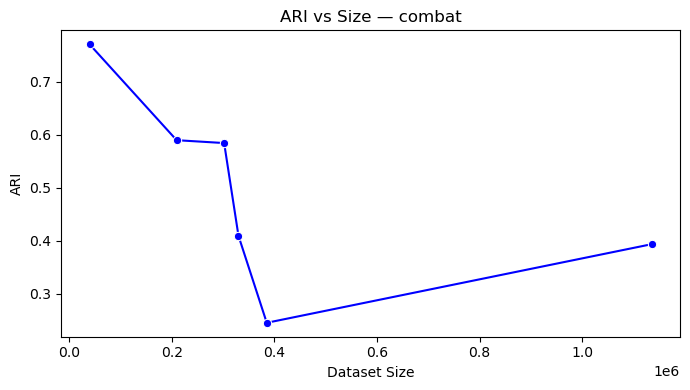

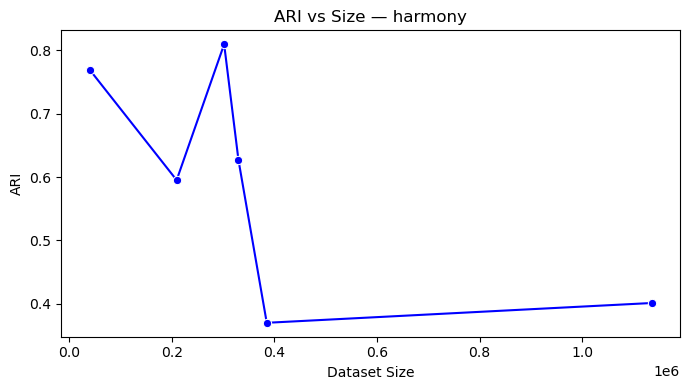

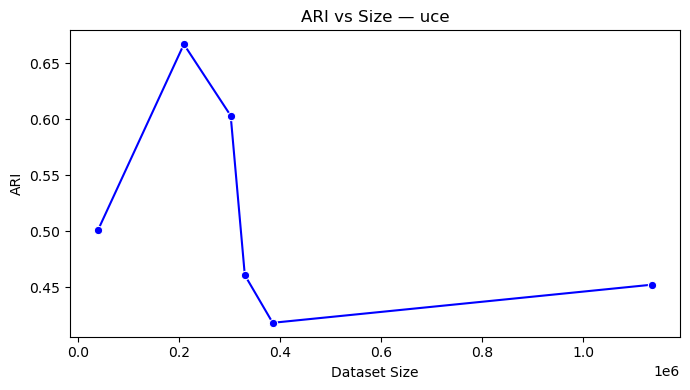

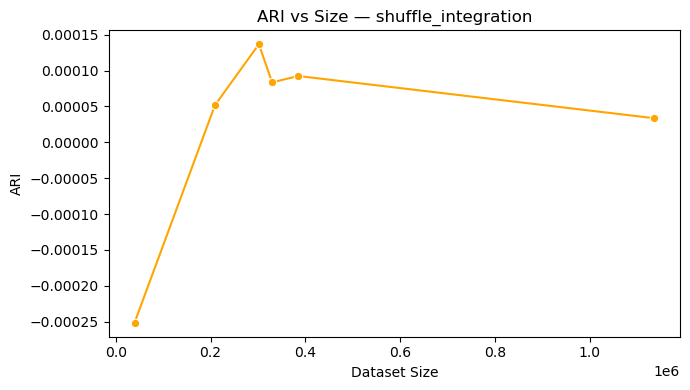

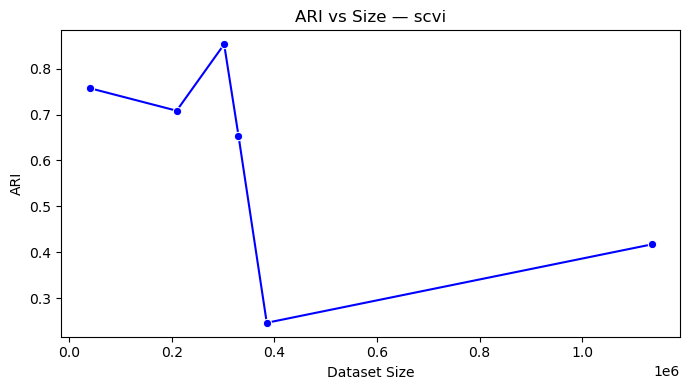

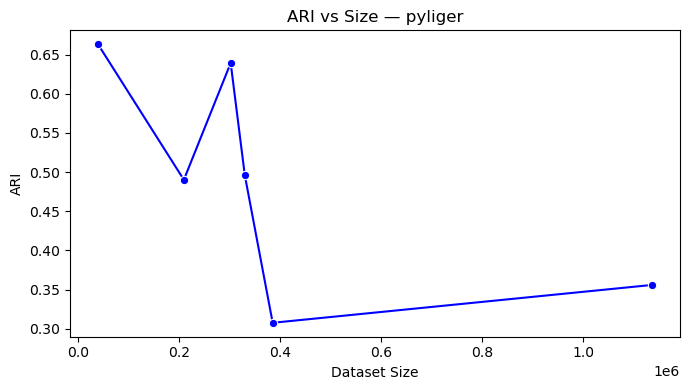

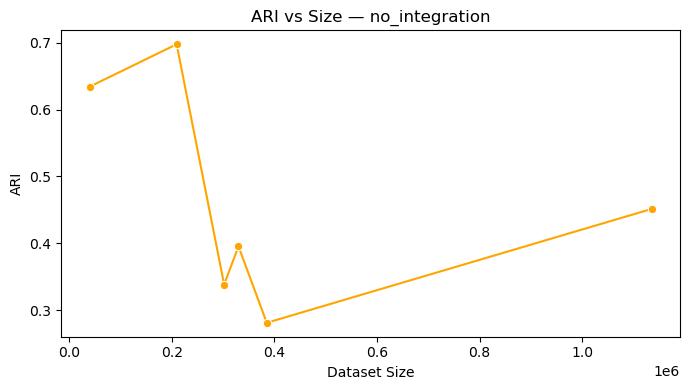

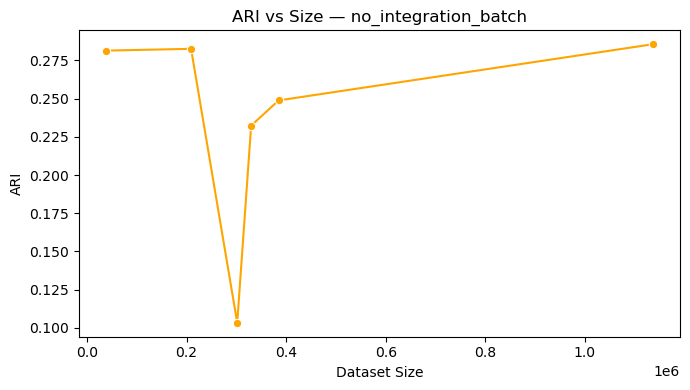

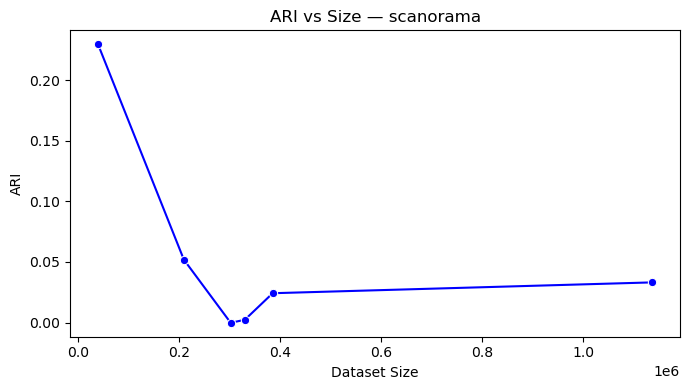

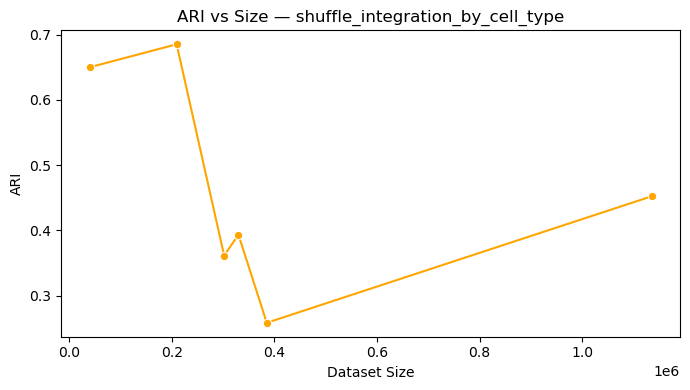

In [57]:
for method in df["method_id"].unique():
    df_m = df_ari[df_ari["method_id"] == method].sort_values("size")
    
    # Decide color: orange if control, blue if not
    is_control = df_m["control_type"].notna().any() and (df_m["control_type"] != "none").any()
    color = "orange" if is_control else "blue"
    
    plt.figure(figsize=(7, 4))
    sns.lineplot(
        data=df_m,
        x="size",
        y="metric_value",
        marker="o",
        color=color,
        errorbar=None, # confidence interval
    )
    
    # force the y-axis scale to be 0 to 1
    
    plt.title(f"ARI vs Size — {method}")
    plt.xlabel("Dataset Size")
    plt.ylabel("ARI")
    plt.tight_layout()
    plt.show()
    


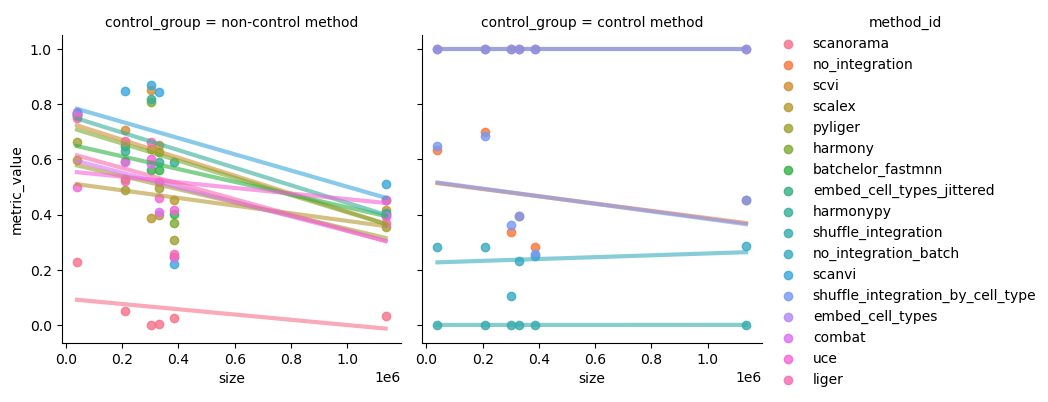

In [69]:
sns.lmplot(data=df_ari, x="size", y="metric_value", hue="method_id", col="control_group", 
           height=4, ci=None, line_kws={'alpha': 0.6, 'linewidth': 3})

lines overlap so use FacetGrid + regplot

In [85]:
palette = sns.color_palette("tab10")

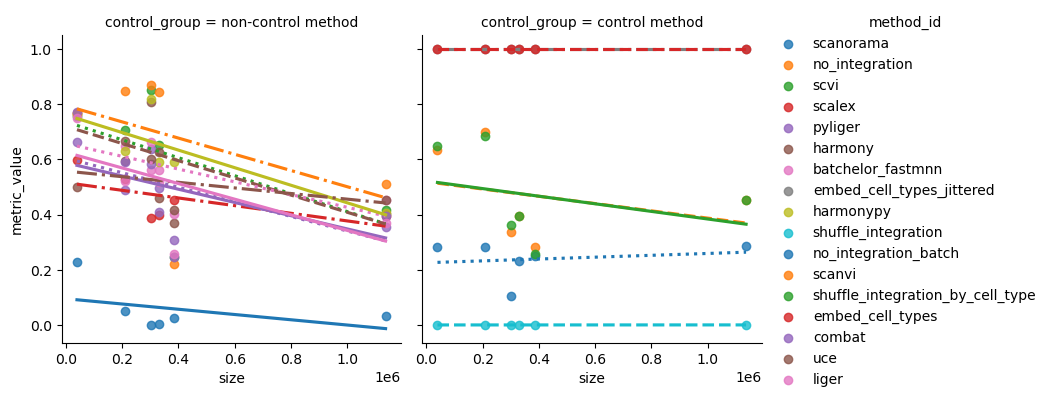

In [86]:
g = sns.FacetGrid(df_ari, col="control_group", hue="method_id", height=4, palette=palette,)

# cycle through line styles manually
line_styles = ["-", "--", ":", "-."]

def reg_with_style(data, color, label, **kwargs):
    idx = list(df_ari["method_id"].unique()).index(label)
    style = line_styles[idx % len(line_styles)]
    sns.regplot(
        data=data,
        x="size",
        y="metric_value",
        color=color,
        label=label,
        ci=None,
        line_kws={'linestyle': style},
        **kwargs
    )

g.map_dataframe(reg_with_style)
g.add_legend()

### ari vs n_genes - scanvi, harmonypy, uce, scvi

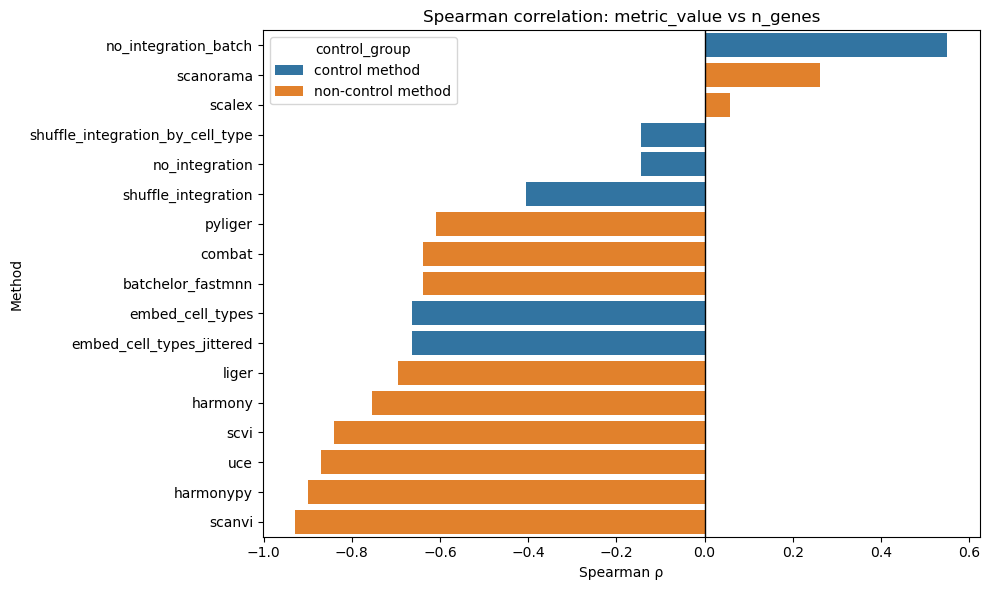

,method,spearman_rho,p_value,n_points,control_group
10,no_integration_batch,0.550782,0.257369,6,control method
0,scanorama,0.260897,0.617534,6,non-control method
3,scalex,0.057977,0.913132,6,non-control method
12,shuffle_integration_by_cell_type,-0.144943,0.784108,6,control method
1,no_integration,-0.144943,0.784108,6,control method
9,shuffle_integration,-0.405840,0.424663,6,control method
4,pyliger,-0.608760,0.199660,6,non-control method
14,combat,-0.637748,0.173071,6,non-control method
6,batchelor_fastmnn,-0.637748,0.173071,6,non-control method
13,embed_cell_types,-0.664211,0.150200,6,control method


In [87]:
spearman_by_method(df_ari, "n_genes")

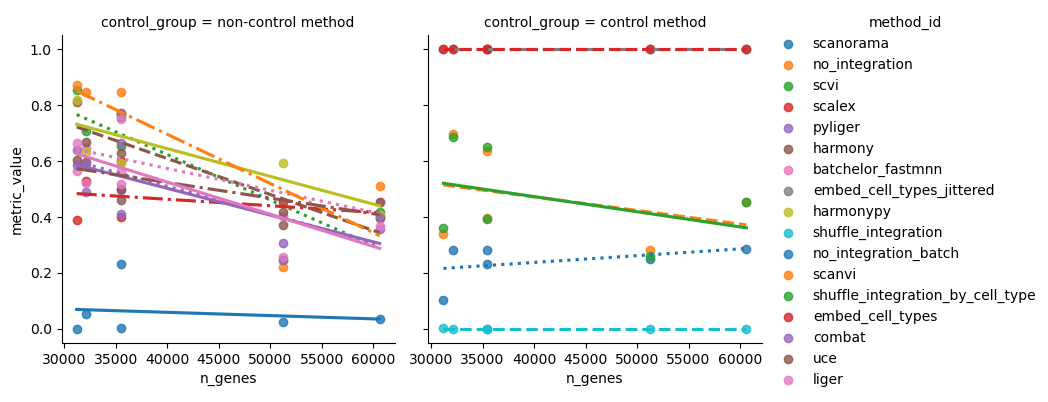

In [92]:
g = sns.FacetGrid(df_ari, col="control_group", hue="method_id", height=4, palette=palette,)

# cycle through line styles manually
line_styles = ["-", "--", ":", "-."]

def reg_with_style(data, color, label, **kwargs):
    idx = list(df_ari["method_id"].unique()).index(label)
    style = line_styles[idx % len(line_styles)]
    sns.regplot(
        data=data,
        x="n_genes",
        y="metric_value",
        color=color,
        label=label,
        ci=None,
        line_kws={'linestyle': style},
        **kwargs
    )

g.map_dataframe(reg_with_style)
g.add_legend()

one trend for one metric&method - look if other metrics show that trend too

lmplot hue=metric

bio metrics vs batch metrics? 

### ari vs n_tissues - no high correlation

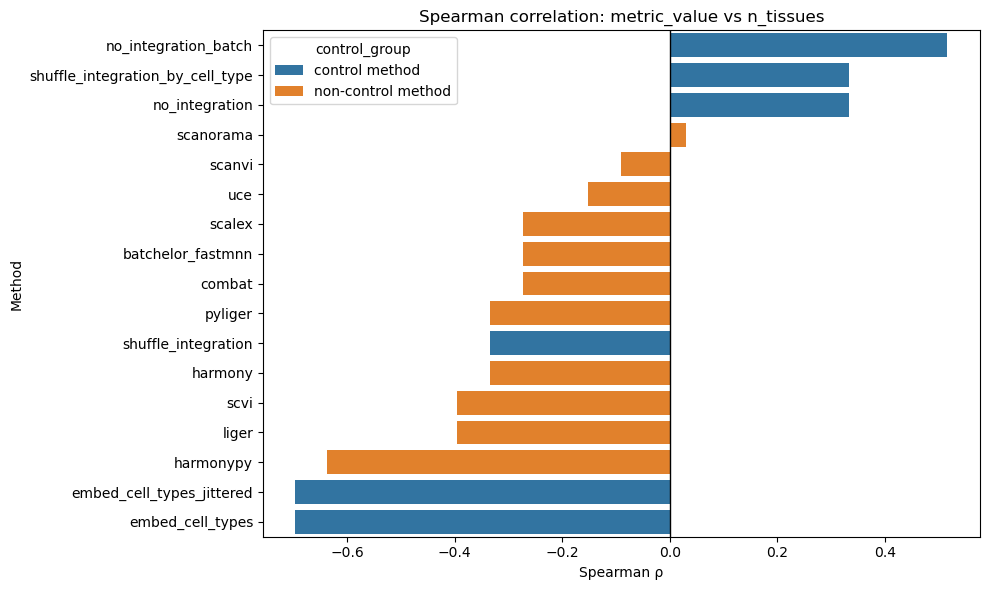

,method,spearman_rho,p_value,n_points,control_group
10,no_integration_batch,0.516100,0.294584,6,control method
12,shuffle_integration_by_cell_type,0.333947,0.517700,6,control method
1,no_integration,0.333947,0.517700,6,control method
0,scanorama,0.030359,0.954476,6,non-control method
11,scanvi,-0.091077,0.863763,6,non-control method
15,uce,-0.151794,0.774058,6,non-control method
3,scalex,-0.273230,0.600355,6,non-control method
6,batchelor_fastmnn,-0.273230,0.600355,6,non-control method
14,combat,-0.273230,0.600355,6,non-control method
4,pyliger,-0.333947,0.517700,6,non-control method


In [94]:
spearman_by_method(df_ari, "n_tissues")

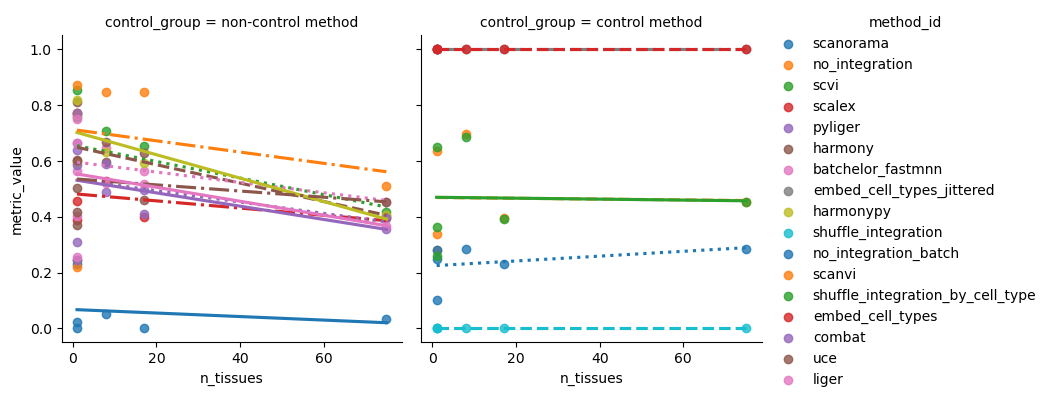

In [91]:
g = sns.FacetGrid(df_ari, col="control_group", hue="method_id", height=4, palette=palette,)

# cycle through line styles manually
line_styles = ["-", "--", ":", "-."]

def reg_with_style(data, color, label, **kwargs):
    idx = list(df_ari["method_id"].unique()).index(label)
    style = line_styles[idx % len(line_styles)]
    sns.regplot(
        data=data,
        x="n_tissues",
        y="metric_value",
        color=color,
        label=label,
        ci=None,
        line_kws={'linestyle': style},
        **kwargs
    )

g.map_dataframe(reg_with_style)
g.add_legend()

### ari vs n_celltypes - no high correlation

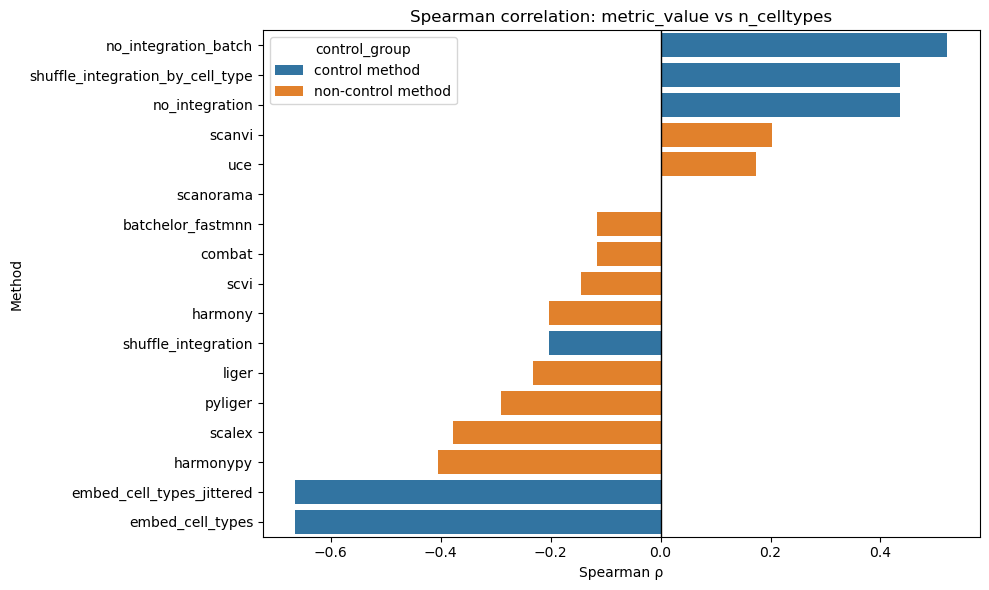

,method,spearman_rho,p_value,n_points,control_group
10,no_integration_batch,0.521794,0.288343,6,control method
12,shuffle_integration_by_cell_type,0.434828,0.388865,6,control method
1,no_integration,0.434828,0.388865,6,control method
11,scanvi,0.202920,0.699798,6,non-control method
15,uce,0.173931,0.741734,6,non-control method
0,scanorama,0.000000,1.000000,6,non-control method
6,batchelor_fastmnn,-0.115954,0.826848,6,non-control method
14,combat,-0.115954,0.826848,6,non-control method
2,scvi,-0.144943,0.784108,6,non-control method
5,harmony,-0.202920,0.699798,6,non-control method


In [99]:
spearman_by_method(df_ari, "n_celltypes")

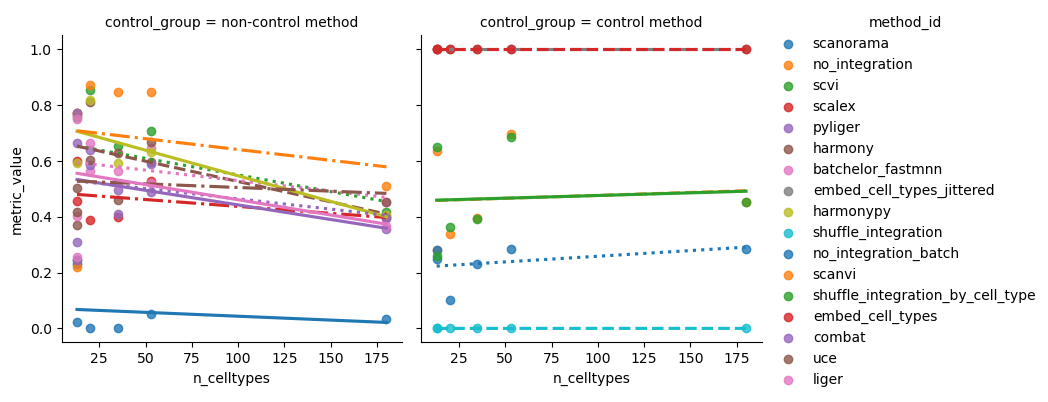

In [100]:
g = sns.FacetGrid(df_ari, col="control_group", hue="method_id", height=4, palette=palette,)

# cycle through line styles manually
line_styles = ["-", "--", ":", "-."]

def reg_with_style(data, color, label, **kwargs):
    idx = list(df_ari["method_id"].unique()).index(label)
    style = line_styles[idx % len(line_styles)]
    sns.regplot(
        data=data,
        x="n_celltypes",
        y="metric_value",
        color=color,
        label=label,
        ci=None,
        line_kws={'linestyle': style},
        **kwargs
    )

g.map_dataframe(reg_with_style)
g.add_legend()

### ari vs n_batches - no high correlation

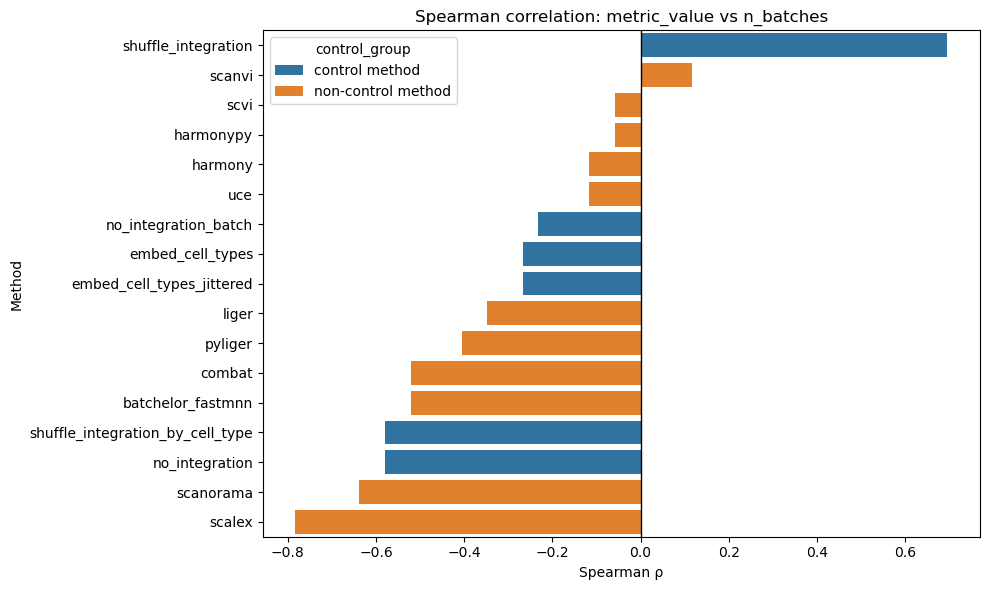

,method,spearman_rho,p_value,n_points,control_group
9,shuffle_integration,0.695725,0.124789,6,control method
11,scanvi,0.115954,0.826848,6,non-control method
2,scvi,-0.057977,0.913132,6,non-control method
8,harmonypy,-0.057977,0.913132,6,non-control method
5,harmony,-0.115954,0.826848,6,non-control method
15,uce,-0.115954,0.826848,6,non-control method
10,no_integration_batch,-0.231908,0.658374,6,control method
13,embed_cell_types,-0.265684,0.610850,6,control method
7,embed_cell_types_jittered,-0.265684,0.610850,6,control method
16,liger,-0.347863,0.499253,6,non-control method


In [96]:
spearman_by_method(df_ari, "n_batches")

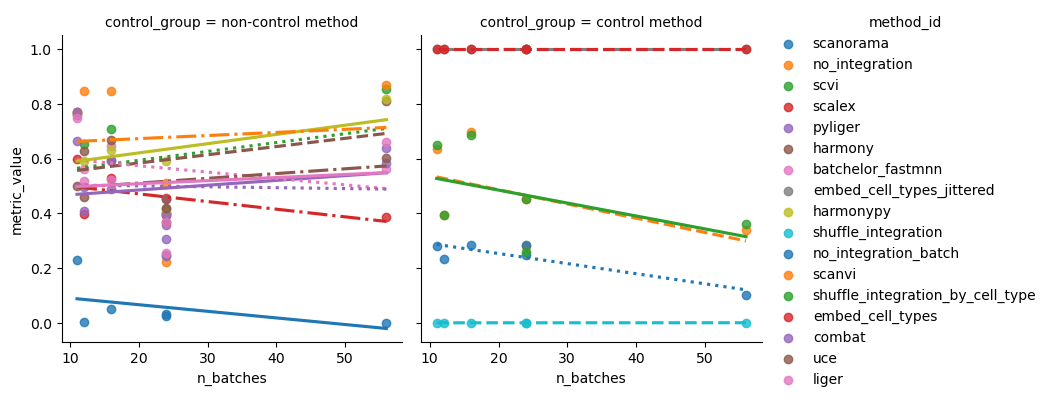

In [101]:
g = sns.FacetGrid(df_ari, col="control_group", hue="method_id", height=4, palette=palette,)

# cycle through line styles manually
line_styles = ["-", "--", ":", "-."]

def reg_with_style(data, color, label, **kwargs):
    idx = list(df_ari["method_id"].unique()).index(label)
    style = line_styles[idx % len(line_styles)]
    sns.regplot(
        data=data,
        x="n_batches",
        y="metric_value",
        color=color,
        label=label,
        ci=None,
        line_kws={'linestyle': style},
        **kwargs
    )

g.map_dataframe(reg_with_style)
g.add_legend()

### ari vs batch_imbalance (CV) - pyliger, liger, harmony, scvi, harmonypy, combat, batchelor_fastmnn

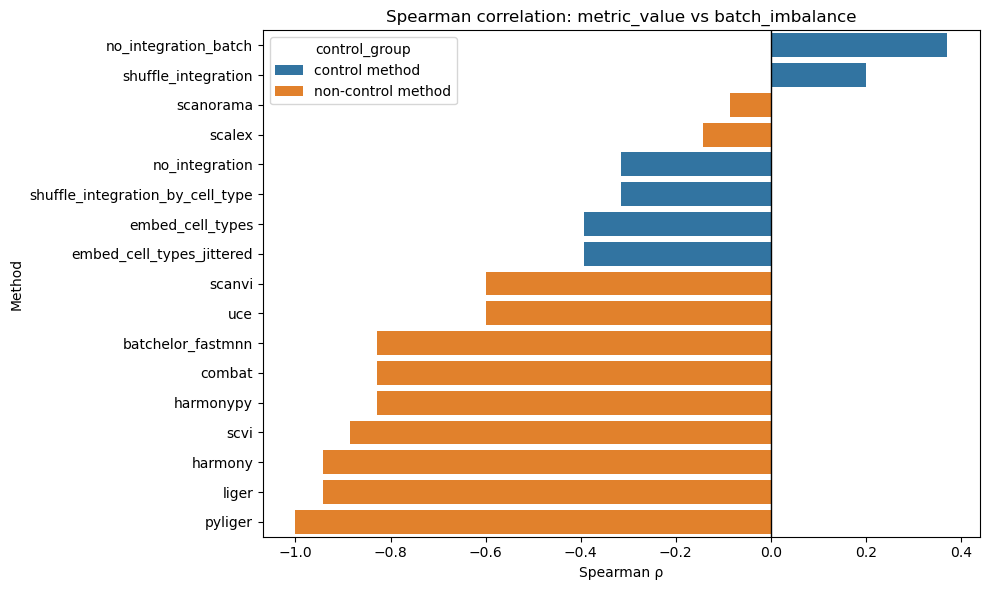

,method,spearman_rho,p_value,n_points,control_group
10,no_integration_batch,0.371429,0.468478,6,control method
9,shuffle_integration,0.200000,0.704000,6,control method
0,scanorama,-0.085714,0.871743,6,non-control method
3,scalex,-0.142857,0.787172,6,non-control method
1,no_integration,-0.314286,0.544093,6,control method
12,shuffle_integration_by_cell_type,-0.314286,0.544093,6,control method
13,embed_cell_types,-0.392792,0.441113,6,control method
7,embed_cell_types_jittered,-0.392792,0.441113,6,control method
11,scanvi,-0.600000,0.208000,6,non-control method
15,uce,-0.600000,0.208000,6,non-control method


In [102]:
spearman_by_method(df_ari, "batch_imbalance")

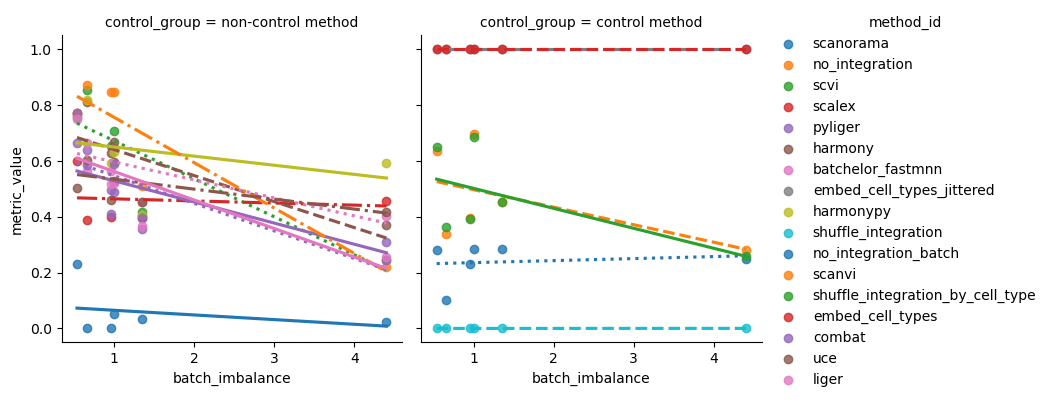

In [103]:
g = sns.FacetGrid(df_ari, col="control_group", hue="method_id", height=4, palette=palette,)

# cycle through line styles manually
line_styles = ["-", "--", ":", "-."]

def reg_with_style(data, color, label, **kwargs):
    idx = list(df_ari["method_id"].unique()).index(label)
    style = line_styles[idx % len(line_styles)]
    sns.regplot(
        data=data,
        x="batch_imbalance",
        y="metric_value",
        color=color,
        label=label,
        ci=None,
        line_kws={'linestyle': style},
        **kwargs
    )

g.map_dataframe(reg_with_style)
g.add_legend()

### ari vs nested_batches - uce, scanvi

nested_batches is categorical, but binary - map to 0 (No) and 1 (Yes). Then:

- Positive Spearman → “Yes” group tends to have higher values”
- Negative Spearman → “No” group tends to have higher values”
- Magnitude near 1 or –1 → groups are strongly separated
- Magnitude near 0 → no monotonic relationship


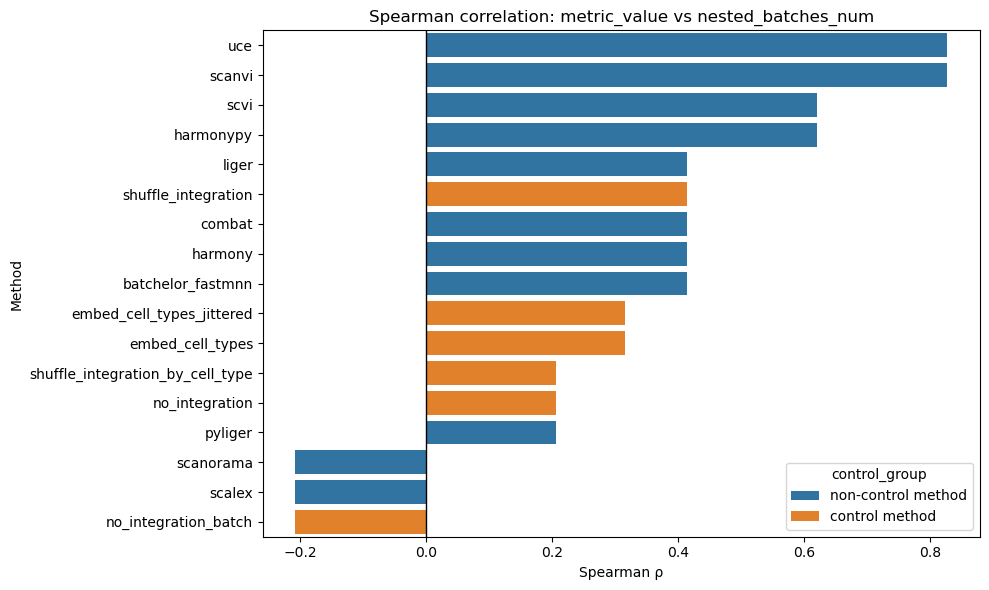

,method,spearman_rho,p_value,n_points,control_group
15,uce,0.828079,0.041795,6,non-control method
11,scanvi,0.828079,0.041795,6,non-control method
2,scvi,0.621059,0.188187,6,non-control method
8,harmonypy,0.621059,0.188187,6,non-control method
16,liger,0.414039,0.414430,6,non-control method
9,shuffle_integration,0.414039,0.414430,6,control method
14,combat,0.414039,0.414430,6,non-control method
5,harmony,0.414039,0.414430,6,non-control method
6,batchelor_fastmnn,0.414039,0.414430,6,non-control method
7,embed_cell_types_jittered,0.316228,0.541470,6,control method


In [111]:
spearman_by_method(df_ari, "nested_batches_num")

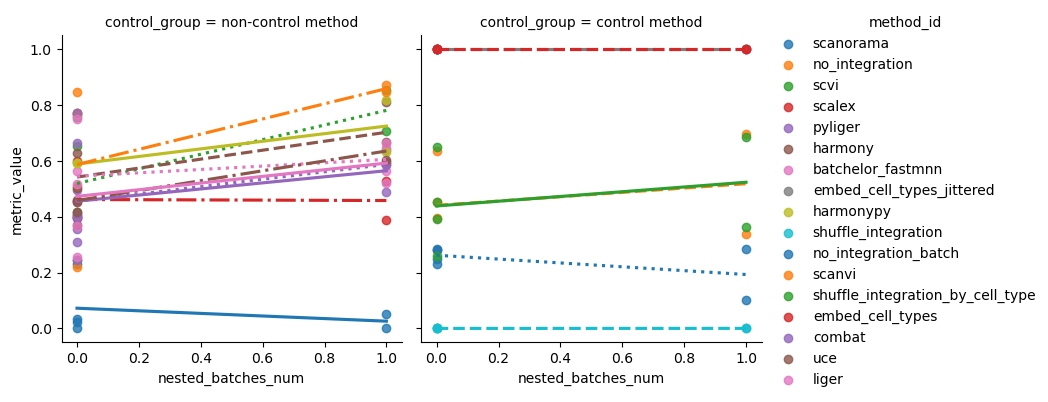

In [117]:
g = sns.FacetGrid(df_ari, col="control_group", hue="method_id", height=4, palette=palette,)

def reg_with_style(data, color, label, **kwargs):
    idx = list(df_ari["method_id"].unique()).index(label)
    style = line_styles[idx % len(line_styles)]
    sns.regplot(
        data=data,
        x="nested_batches_num",
        y="metric_value",
        color=color,
        label=label,
        ci=None,
        line_kws={'linestyle': style},
        **kwargs
    )

g.map_dataframe(reg_with_style)
g.add_legend()

### ari vs n_samples - combat, batchelor_fastmnn, pyliger, liger

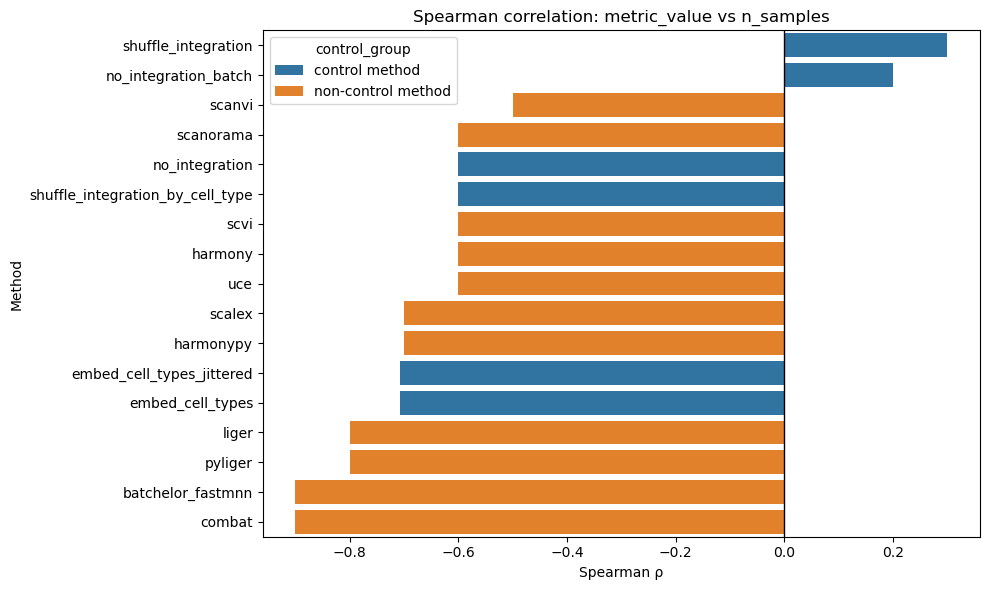

,method,spearman_rho,p_value,n_points,control_group
9,shuffle_integration,0.300000,0.623838,6,control method
10,no_integration_batch,0.200000,0.747060,6,control method
11,scanvi,-0.500000,0.391002,6,non-control method
0,scanorama,-0.600000,0.284757,6,non-control method
1,no_integration,-0.600000,0.284757,6,control method
12,shuffle_integration_by_cell_type,-0.600000,0.284757,6,control method
2,scvi,-0.600000,0.284757,6,non-control method
5,harmony,-0.600000,0.284757,6,non-control method
15,uce,-0.600000,0.284757,6,non-control method
3,scalex,-0.700000,0.188120,6,non-control method


In [126]:
spearman_by_method(df_ari, "n_samples")

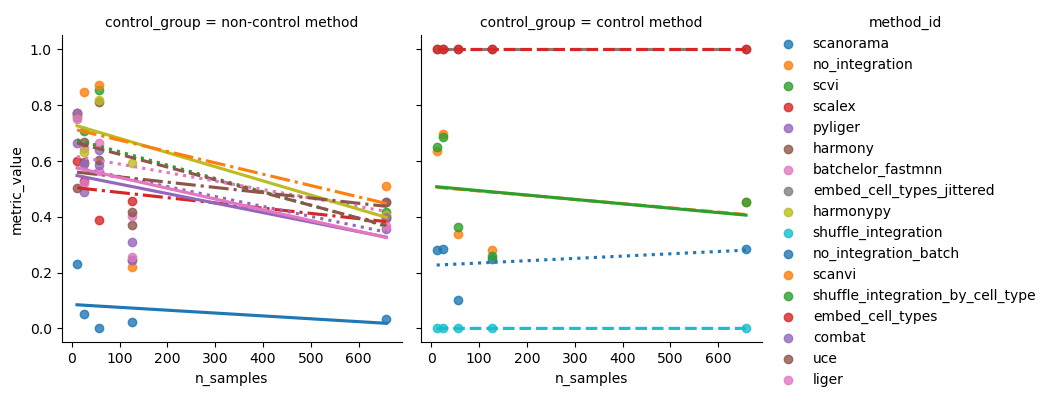

In [131]:
g = sns.FacetGrid(df_ari, col="control_group", hue="method_id", height=4, palette=palette,)

def reg_with_style(data, color, label, **kwargs):
    idx = list(df_ari["method_id"].unique()).index(label)
    style = line_styles[idx % len(line_styles)]
    sns.regplot(
        data=data,
        x="n_samples",
        y="metric_value",
        color=color,
        label=label,
        ci=None,
        line_kws={'linestyle': style},
        **kwargs
    )

g.map_dataframe(reg_with_style)
g.add_legend()

### ari vs n_donors - no high correlation

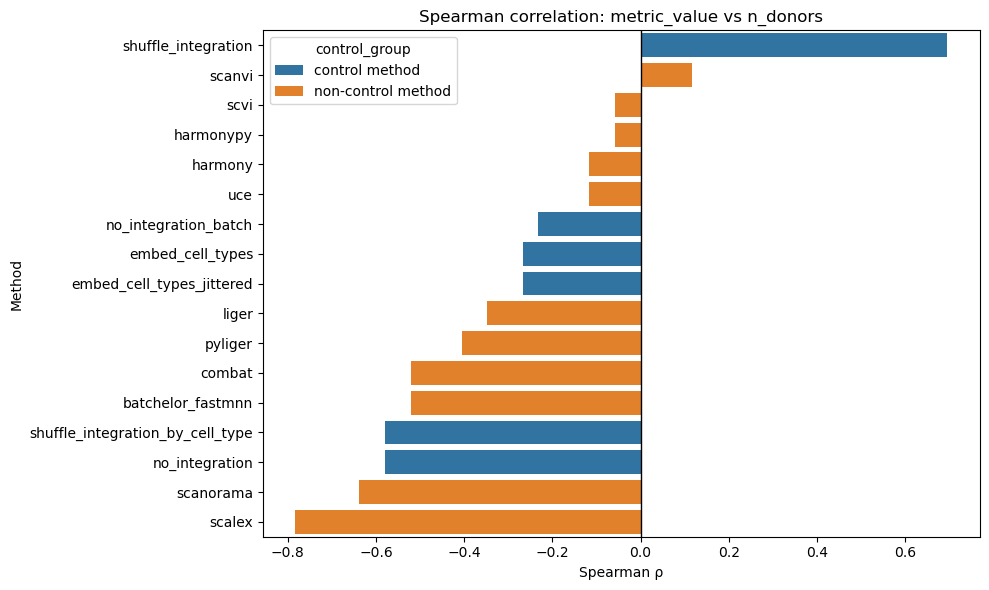

,method,spearman_rho,p_value,n_points,control_group
9,shuffle_integration,0.695725,0.124789,6,control method
11,scanvi,0.115954,0.826848,6,non-control method
2,scvi,-0.057977,0.913132,6,non-control method
8,harmonypy,-0.057977,0.913132,6,non-control method
5,harmony,-0.115954,0.826848,6,non-control method
15,uce,-0.115954,0.826848,6,non-control method
10,no_integration_batch,-0.231908,0.658374,6,control method
13,embed_cell_types,-0.265684,0.610850,6,control method
7,embed_cell_types_jittered,-0.265684,0.610850,6,control method
16,liger,-0.347863,0.499253,6,non-control method


In [ ]:
spearman_by_method(df_ari, "n_donors")

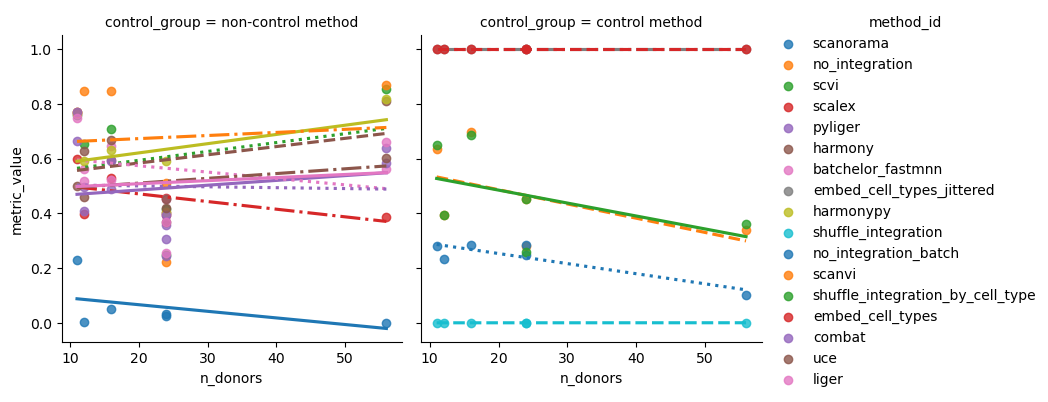

In [132]:
g = sns.FacetGrid(df_ari, col="control_group", hue="method_id", height=4, palette=palette,)

def reg_with_style(data, color, label, **kwargs):
    idx = list(df_ari["method_id"].unique()).index(label)
    style = line_styles[idx % len(line_styles)]
    sns.regplot(
        data=data,
        x="n_donors",
        y="metric_value",
        color=color,
        label=label,
        ci=None,
        line_kws={'linestyle': style},
        **kwargs
    )

g.map_dataframe(reg_with_style)
g.add_legend()